In [1]:
import sys
import os
import warnings

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

warnings.filterwarnings("ignore")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from umap import UMAP

from src.msde import MeanShiftDensityEnhancement

In [3]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=None, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=None, download=True)

In [4]:
train_dataset.data = (train_dataset.data.float() / 255.0 - 0.1307) / 0.3081
test_dataset.data = (test_dataset.data.float() / 255.0 - 0.1307) / 0.3083

In [5]:
def train(model, device, epochs=50, warm=10):
    history = []

    model.to(device)
    data = train_dataset.data.to(device)
    data = data.unsqueeze(1)
    labels = train_dataset.targets.to(device)

    model.train()
    reconstruction = nn.MSELoss()
    classification = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        for i in range(0, 6):
          rng = np.random.default_rng(seed=i+42)
          idx = rng.integers(0, len(data), size=10000)
          x = data[idx]
          y = labels[idx]
          if x.shape[0] == 0 or y.shape[0] == 0:
            continue

          optimizer.zero_grad()
          x_recon, y_pred = model(x, epoch)
          loss = reconstruction(x_recon, torch.sigmoid(x)) + classification(y_pred, y)

          loss.backward()
          optimizer.step()

        history.append(loss.item())
        if (epoch % 10 == 0):
            print(f"Epoch {epoch:02d} | Loss: {loss.item():.4f}")

    return history

In [19]:
def visualize(model, device):
    model.to(device)

    train_data = train_dataset.data.to(device)
    train_data = train_data.unsqueeze(1)[:10000]
    test_data = test_dataset.data.to(device)
    test_data = test_data.unsqueeze(1)[:10000]

    model.eval()
    with torch.no_grad():
        # Get encoder outputs
        encoder_output_train = model.encoder(train_data)
        encoder_output_test = model.encoder(test_data)

        # Flatten encoder outputs to be (N, embed_dim) for MSDE
        train_emb_before = encoder_output_train.flatten(start_dim=1)
        test_emb_before = encoder_output_test.flatten(start_dim=1)

        # Pass flattened embeddings through MSDE
        train_emb_after, train_dist, _ = model.msde(train_emb_before)
        test_emb_after, test_dist, _ = model.msde(test_emb_before)

        # Convert to numpy for PCA/UMAP
        train_emb_before = train_emb_before.cpu().numpy()
        train_emb_after = train_emb_after.cpu().numpy()
        test_emb_before = test_emb_before.cpu().numpy()
        test_emb_after = test_emb_after.cpu().numpy()

        # Convert distances to numpy too
        train_dist = train_dist.cpu().numpy()
        test_dist = test_dist.cpu().numpy()

    train_targets = train_dataset.targets[:10000]
    test_targets = test_dataset.targets[:10000]
    digit_names = [f"Digit {i}" for i in range(10)]

    # numpy versions of targets for masking
    train_targets_np = train_targets.numpy() if hasattr(train_targets, 'numpy') else np.array(train_targets)
    test_targets_np = test_targets.numpy() if hasattr(test_targets, 'numpy') else np.array(test_targets)

    def plot_3d_grid(train_before, train_after, test_before, test_after, method_name):
        fig = plt.figure(figsize=(16, 14))

        panels = [
            (train_before, train_targets, f'Train {method_name} before MSDE', 1),
            (train_after,  train_targets, f'Train {method_name} after MSDE',  2),
            (test_before,  test_targets,  f'Test {method_name} before MSDE',  3),
            (test_after,   test_targets,  f'Test {method_name} after MSDE',   4),
        ]

        last_sc = None
        for data_xyz, targets, title, pos in panels:
            ax = fig.add_subplot(2, 2, pos, projection='3d')
            last_sc = ax.scatter(data_xyz[:, 0], data_xyz[:, 1], data_xyz[:, 2],
                                  c=targets, cmap='tab10', alpha=0.6, s=5)
            ax.set_title(title)
            ax.set_xlabel('Dim 1')
            ax.set_ylabel('Dim 2')
            ax.set_zlabel('Dim 3')

        handles, labels = last_sc.legend_elements()
        fig.legend(handles, digit_names, bbox_to_anchor=(1.05, 0.9), loc='upper left')

        plt.tight_layout()
        plt.show()

    def plot_distance_histograms(train_dist, test_dist, train_targets_np, test_targets_np):
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        axes = axes.flatten()

        for digit in range(10):
            ax = axes[digit]
            train_vals = train_dist[train_targets_np == digit]
            test_vals = test_dist[test_targets_np == digit]

            ax.hist(train_vals, bins=30, alpha=0.6, label='Train', color='tab:blue', density=True)
            ax.hist(test_vals, bins=30, alpha=0.6, label='Test', color='tab:orange', density=True)
            ax.set_title(f'Digit {digit}')
            ax.set_xlabel('Total distance')
            ax.set_ylabel('Density')

        axes[0].legend()
        plt.suptitle('Total Distance Distribution by Class (MSDE)', y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()

    # --- PCA (3D) ---
    pca = PCA(n_components=3)
    train_pca_before = pca.fit_transform(train_emb_before)
    train_pca_after = pca.transform(train_emb_after)
    test_pca_before = pca.transform(test_emb_before)
    test_pca_after = pca.transform(test_emb_after)

    plot_3d_grid(train_pca_before, train_pca_after, test_pca_before, test_pca_after, 'PCA')

    # --- UMAP (3D) ---
    umap = UMAP(n_components=3)
    train_umap_before = umap.fit_transform(train_emb_before)
    train_umap_after = umap.transform(train_emb_after)
    test_umap_before = umap.transform(test_emb_before)
    test_umap_after = umap.transform(test_emb_after)

    plot_3d_grid(train_umap_before, train_umap_after, test_umap_before, test_umap_after, 'UMAP')

    # --- Total distance histograms per class ---
    plot_distance_histograms(train_dist, test_dist, train_targets_np, test_targets_np)

In [7]:
def knn_classifiy(model, device):
    model.eval()
    with torch.no_grad():
        # Use a subset for consistency with visualization and memory constraints
        subset_size = 10000

        train_data_subset = train_dataset.data.to(device).unsqueeze(1)[:subset_size]
        train_labels_subset = train_dataset.targets[:subset_size]
        test_data_subset = test_dataset.data.to(device).unsqueeze(1)[:subset_size]
        test_labels_subset = test_dataset.targets[:subset_size]

        # Get encoder outputs
        encoder_output_train = model.encoder(train_data_subset)
        encoder_output_test = model.encoder(test_data_subset)

        # Flatten encoder outputs (before msde)
        train_emb_before = encoder_output_train.flatten(start_dim=1).cpu().numpy()
        test_emb_before = encoder_output_test.flatten(start_dim=1).cpu().numpy()

        # Pass flattened embeddings through msde (after msde)
        train_emb_after, _, _ = model.msde(torch.from_numpy(train_emb_before).to(device))
        test_emb_after, _, _ = model.msde(torch.from_numpy(test_emb_before).to(device))
        train_emb_after = train_emb_after.cpu().numpy()
        test_emb_after = test_emb_after.cpu().numpy()

        # KNN on embeddings before msde
        knn_before = KNeighborsClassifier(n_neighbors=5)
        knn_before.fit(train_emb_before, train_labels_subset)
        preds_before = knn_before.predict(train_emb_before)
        accuracy_before = accuracy_score(train_labels_subset, preds_before)
        print(f"KNN Accuracy (Encoder Embeddings - Before msde): {accuracy_before:.4f}")

        # KNN on embeddings after msde
        knn_after = KNeighborsClassifier(n_neighbors=5)
        knn_after.fit(train_emb_after, train_labels_subset)
        preds_after = knn_after.predict(train_emb_after)
        accuracy_after = accuracy_score(train_labels_subset, preds_after)
        print(f"KNN Accuracy (msde Embeddings - After msde): {accuracy_after:.4f}")

In [8]:
def get_cosine_schedule(timesteps, s=0.008):
    steps = np.arange(timesteps + 1)
    
    f_t = np.cos(((steps / timesteps) + s) / (1 + s) * (np.pi / 2)) ** 2
    alpha_bar = f_t / f_t[0]
    
    return alpha_bar[::-1]

In [9]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
        )

    def forward(self, x):
        return self.encoder(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(x)

class AutoEncoder(nn.Module):
    def __init__(self, epochs=100, warm=50, num_classes=10):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
        self.msde = MeanShiftDensityEnhancement(k=50, max_iters_shift=50, device="mps", use_chunking=True, learn_learning_rate=True)
        self.warm = warm
        self.gates = get_cosine_schedule(epochs-warm)

        with torch.no_grad():
            probe = self.encoder(torch.zeros(1, 1, 28, 28))
        self.shape = probe.shape[1:]
        embed_dim = probe.flatten(1).shape[1]
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x, epoch=0):
        x = self.encoder(x)
        x = x.flatten(1)
        if epoch >= self.warm:
            x, _, _ = self.msde(x, self.gates[epoch-self.warm])
        y = self.classifier(x)
        x = x.reshape(-1, *self.shape)
        x = self.decoder(x)
        return x, y

In [10]:
warm = 50
epochs = 60
model = AutoEncoder(epochs, warm).float()
history = train(model, "mps", epochs=epochs, warm=warm)

Epoch 00 | Loss: 2.2960
Epoch 10 | Loss: 0.3496
Epoch 20 | Loss: 0.1671
Epoch 30 | Loss: 0.0933
Epoch 40 | Loss: 0.0660
Epoch 50 | Loss: 0.0504


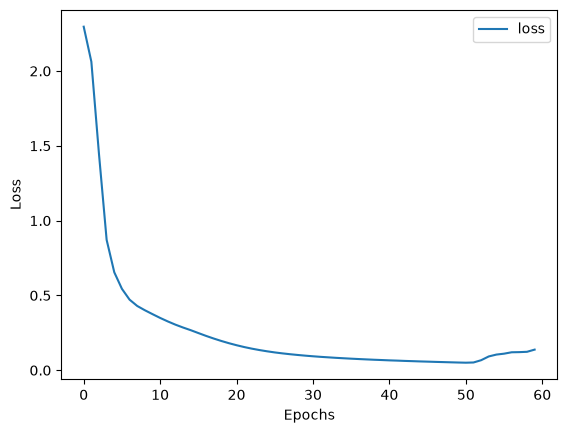

In [11]:
plt.plot(history, label="loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

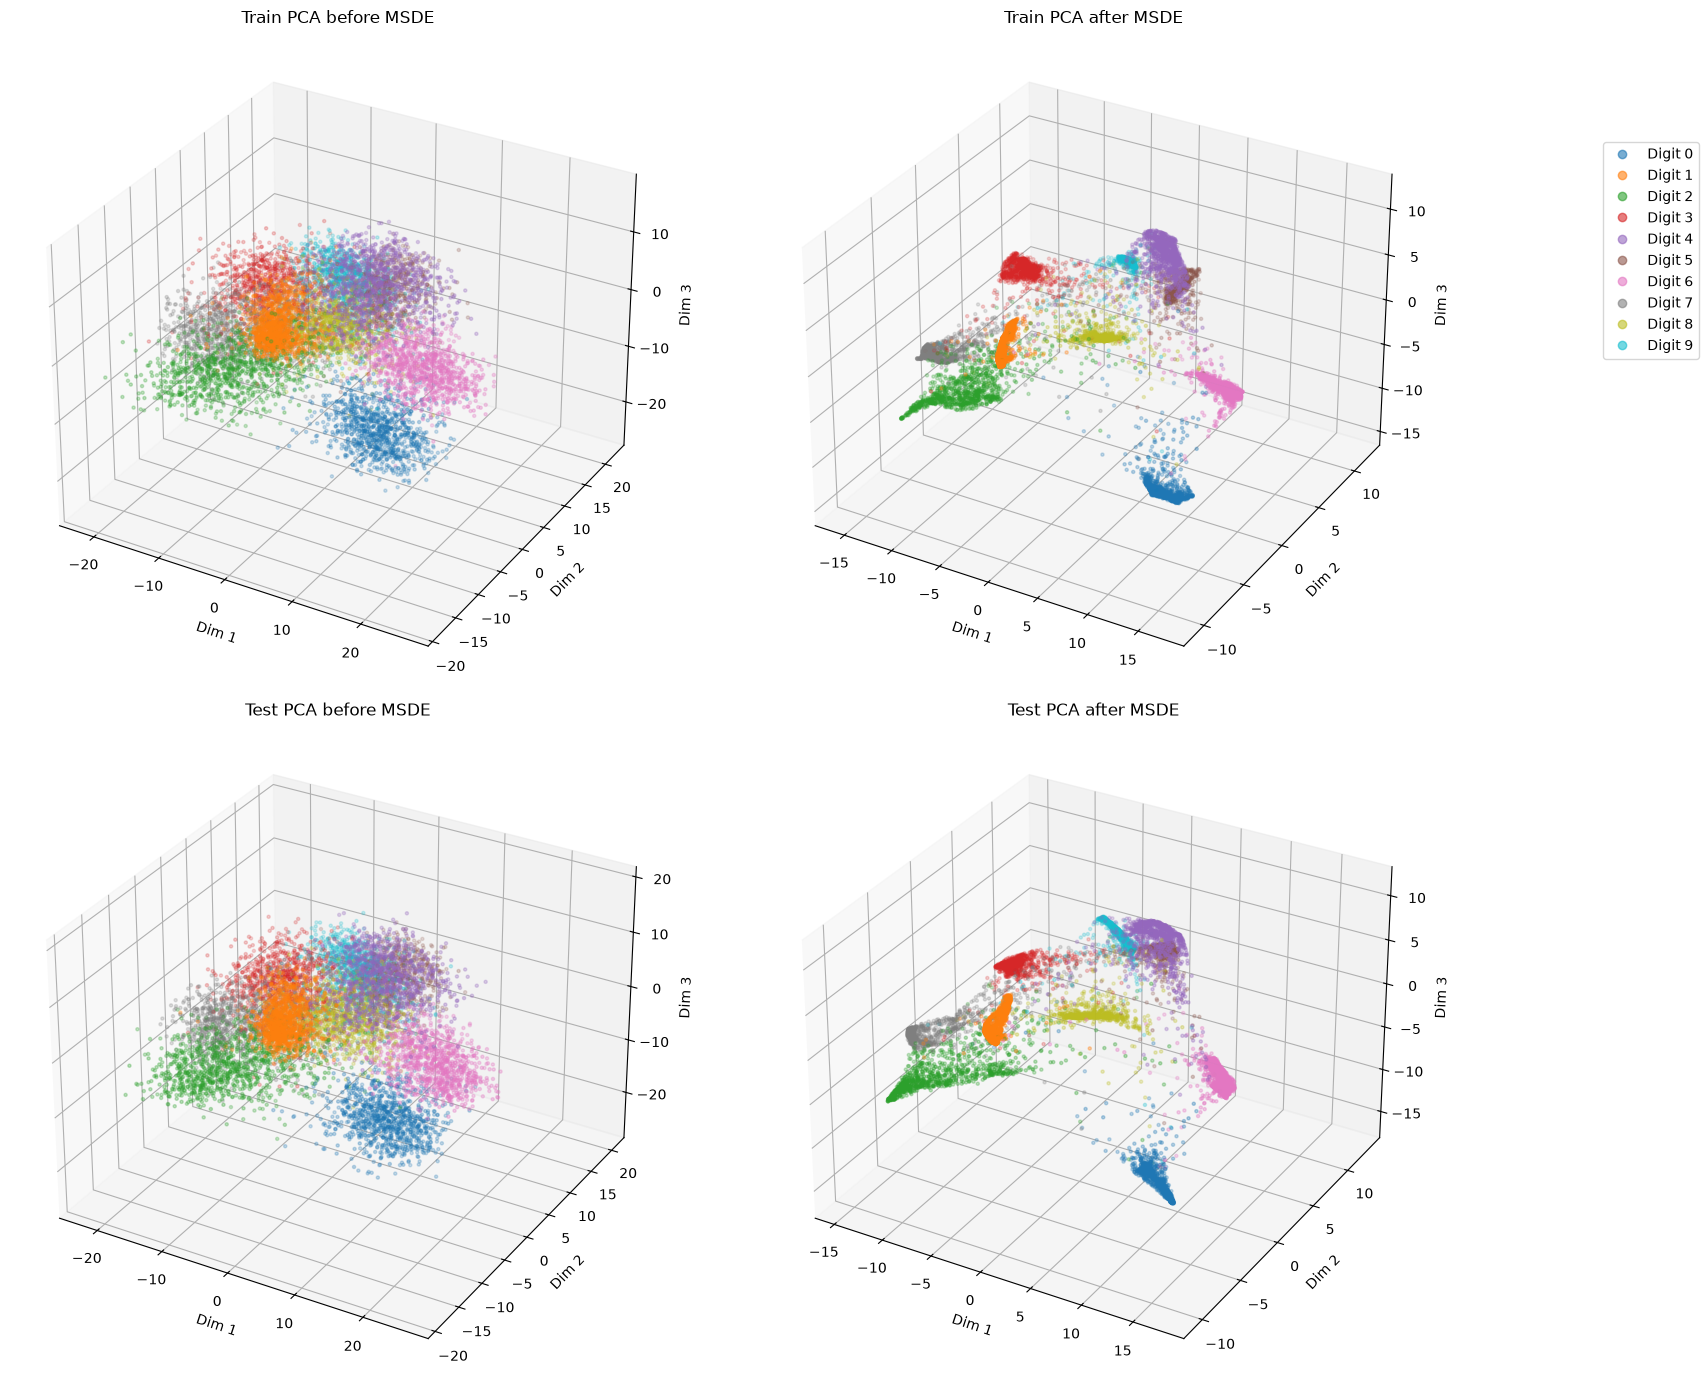

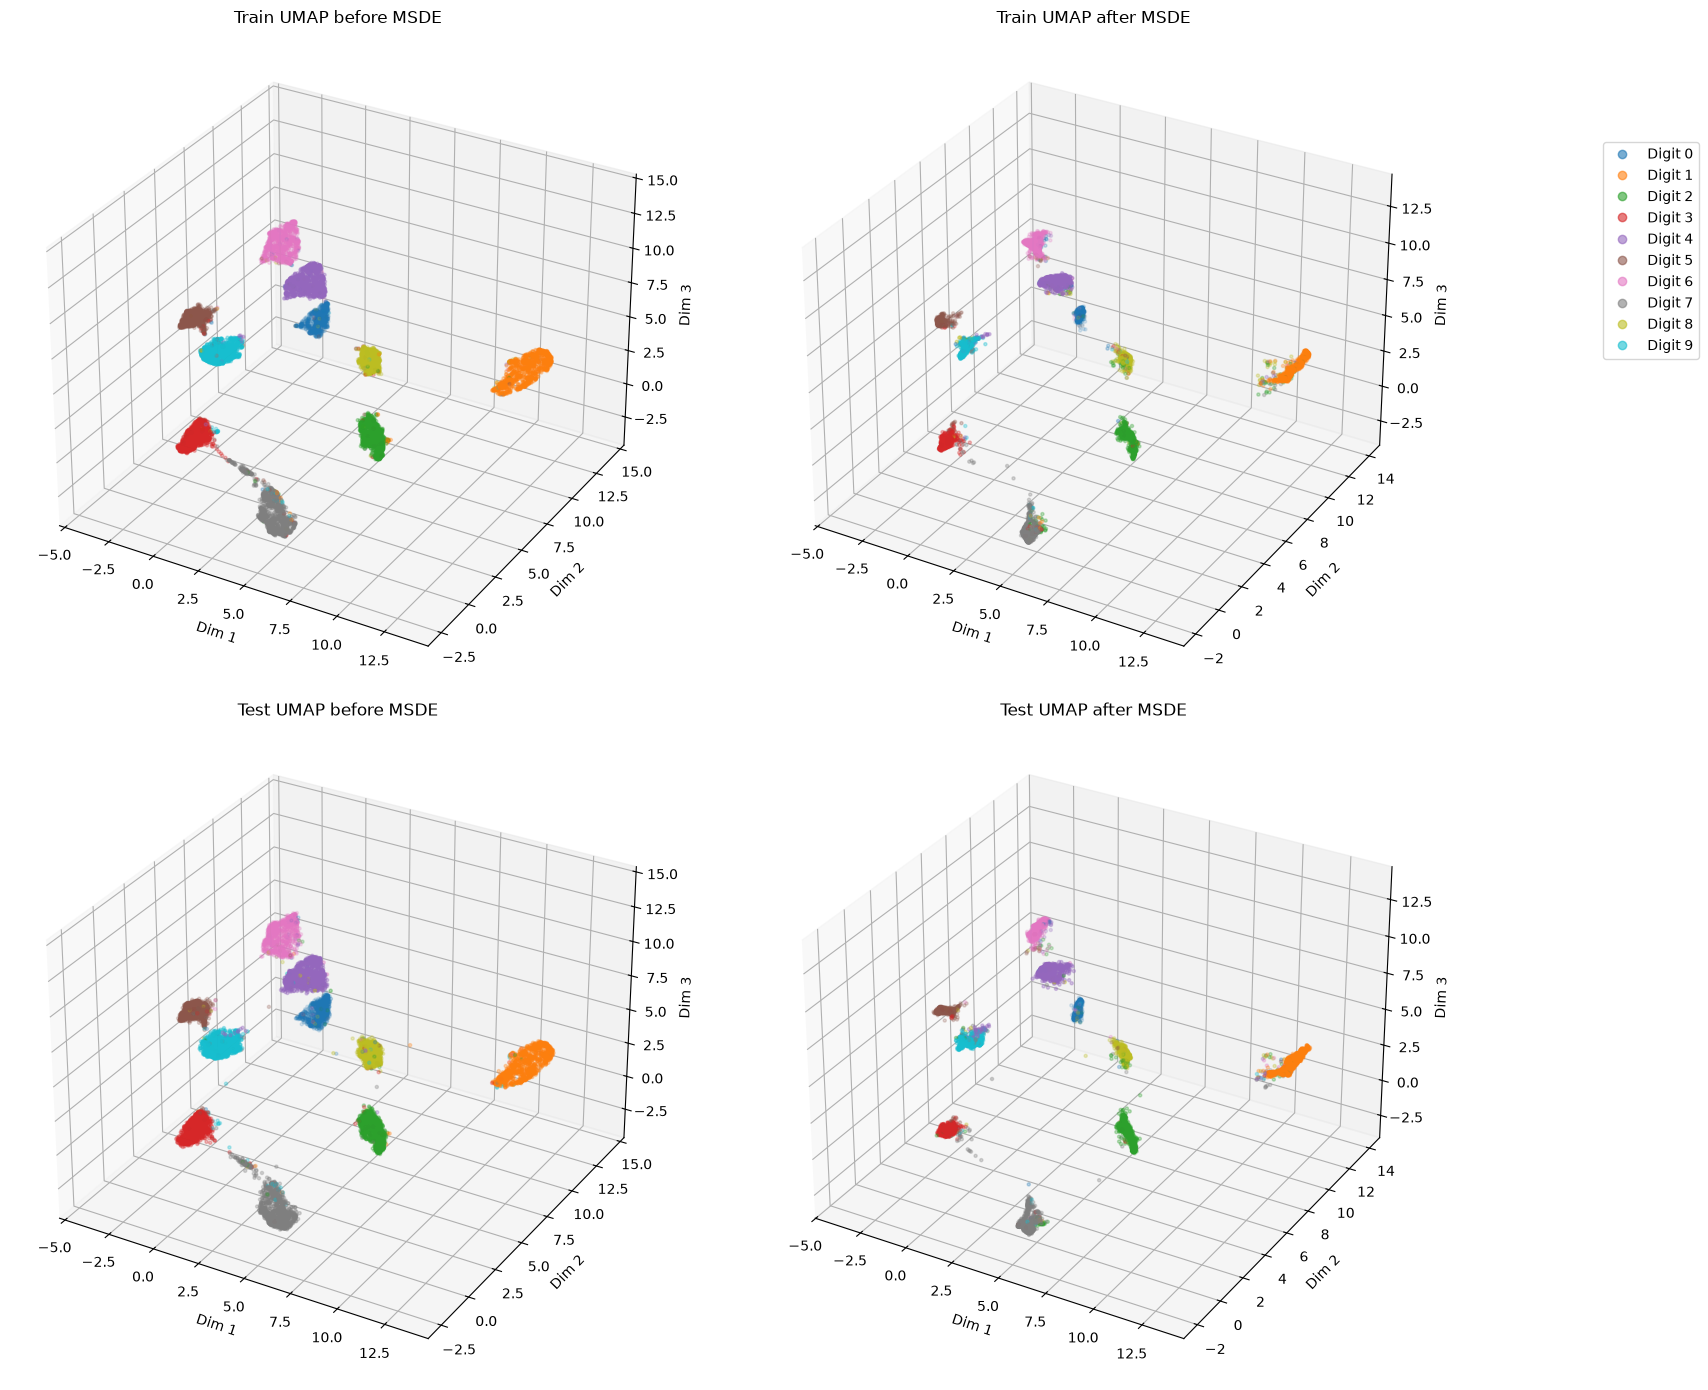

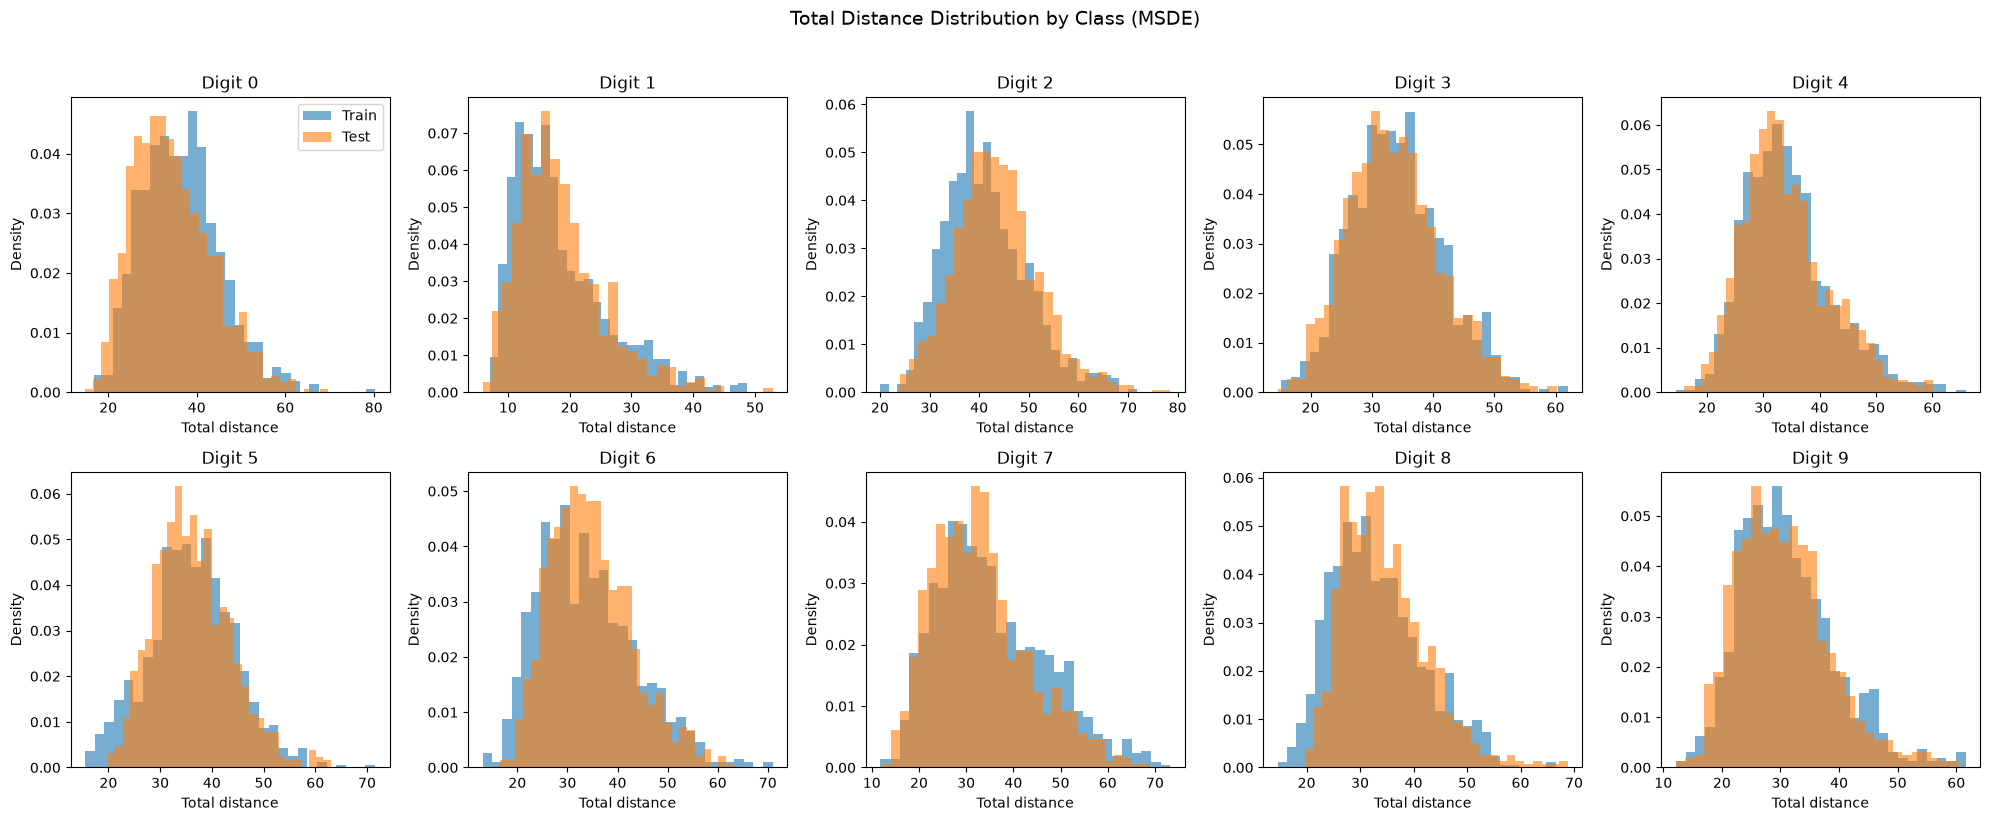

In [20]:
visualize(model, "mps")

In [13]:
knn_classifiy(model, "mps")

KNN Accuracy (Encoder Embeddings - Before msde): 0.9845
KNN Accuracy (msde Embeddings - After msde): 0.9718


In [14]:
model.msde.learnable_parameters

{'learning_rate': Parameter containing:
 tensor(0.2478, device='mps:0', requires_grad=True)}